# 05 - Inertia

## Purpose

This notebook continues a series working toward an accurate,
mathematically proven servo control loop, built on empirical data. Notebook
01 established the coast back-EMF as a direct speed signal and fitted the
coast friction. Notebook 04 measures the friction from the drive side. This
notebook measures the remaining constant of the mechanical equation, the
inertia, and does so in units the data supports.

The motor's torque constant is unknown, so the inertia is measured as
current per unit acceleration, $J_i$, in amperes per (wiper V/s$^2$). With
it the mechanical equation reads

$$J_i\,\dot\omega = i - i_c\,\mathrm{sign}(\omega) - i_v\,\omega ,$$

where $i$ is the winding current, $\omega$ the output speed in wiper V/s,
and $i_c$, $i_v$ the Coulomb and viscous friction in current units. Every
term is measured. Nothing in it needs the torque constant or the gear
ratio.

This notebook has three jobs:

1. Measure $J_i$ from the rise curve, the speed reached after drive steps
   of five lengths, by integrating the equation over each step with the
   measured current (route A, section 5).
2. Measure $J_i$ a second way, from the coast deceleration of notebook 01
   and the drive-side friction line, and compare (route B, section 6).
3. Establish the repeatability of every estimate across five recordings
   and show which speed signal makes the measurement work (section 7).

The dataset is one test session on a 2-cell lithium battery, five step
recordings and the five spin-down recordings of notebook 01, all captured
in one session without recharging, with the duty-grid recordings of
notebook 04 for the friction line.


## 1. Test setup

The device under test is an SG90-class hobby servo with its stock
electronics replaced by a custom controller board. The signal chain is the
one described in notebooks 00 and 01, summarized here with what this
notebook needs.

- A brushed DC motor driven by an H-bridge with 20 kHz PWM, center
  aligned, under slow decay throughout this notebook. **Drive** connects
  the supply across the motor. The OFF portion of each period is **brake**,
  the winding shorted through the two low-side switches. **Coast** turns
  every switch off, so both terminals float.
- A gear train couples the motor to the output shaft. A potentiometer on
  the output shaft is read by the MCU's 12-bit ADC. Position stays in
  wiper volts, speed in wiper V/s, acceleration in wiper V/s$^2$.
- A 33 mOhm shunt resistor in the motor return path, amplified with gain
  15.0, gives the motor current channel. Current crosses the shunt only
  while the bridge drives. In brake it recirculates through the low-side
  switches, so the crest-scan sample of a slow-decay period reads the
  winding current in the drive window.
- Both motor terminals are read through 20 kOhm / 10 kOhm resistor
  dividers, channels `vmotor_a` and `vmotor_b`, with the bottom leg of each
  divider returned to a bias node of about 0.62 V, so that a terminal down
  to -1.2 V stays readable. During coast the difference of the two
  terminals is the back-EMF (notebook 01, section 6.1).
- The ADC runs two five-channel scans per 50 us period, at the crest and
  trough of the PWM counter. Under slow decay the crest scan sees the drive
  state. The controller streams one frame per period with a CRC, and
  corrupted frames become missing samples (verified in section 4).

Power is a 2-cell lithium battery, nominal 7.4 V, read at the driven
terminal during the 30% drive steps as 7.23 to 7.32 V (the rail column of
section 3). The recordings were taken in one session without recharging.


## 2. Constants and unit conversions

All conversions from ADC counts to physical units use the constants below,
the same as notebooks 00 and 01.

| Quantity | Value |
|---|---|
| ADC resolution | 12 bit (0..4095 counts) |
| ADC reference | VDD, nominal 3.300 V |
| Motor terminal divider | 20 kOhm top / 10 kOhm bottom, bottom leg returned to the terminal bias |
| Terminal bias $V_B$, nominal | 430 Ohm / 100 Ohm from VDD, 0.623 V |
| Terminal bias $V_B$, measured | per recording, from the segment-0 baseline (section 3) |
| Current shunt | 33 mOhm |
| Current amplifier gain | 15.0 |
| Control period | 50 us (20 kHz) |
| PWM counter | 1200 timer ticks per half period, center aligned |
| Duty encoding | signed, 32767 = 100% |
| Current sampling floor | 160 timer ticks = 13.3% duty |
| Voltage sampling floor | 210 timer ticks = 17.5% duty |

A terminal voltage $V_t$ reaches the ADC pin as $\text{tap} = V_t / 3 +
2 V_B / 3$, so $V_t = 3\,\text{tap} - 2 V_B$ with the measured $V_B$ of the
recording. The difference of the two terminals is bias-free, $v_A - v_B =
3\,(\text{tap}_A - \text{tap}_B)$ in ADC volts. All drive steps in this
notebook are at 30% duty, above both sampling floors, so every crest-scan
current and terminal sample of a drive step is settled.

Two derived units are specific to this notebook. Speed in wiper V/s comes
from the coast EMF through the slope $k_e$ in V per wiper V/s, remeasured
in section 5.1. The inertia $J_i$ is in A per (wiper V/s$^2$), and the
friction constants $i_c$ and $i_v$ in A and A per (wiper V/s). The
mechanical time constant $J_i / i_v$ is in seconds, since the units of
$\omega$ cancel.

Two caveats carry over from notebook 00. The ADC reference is the design
value, so every voltage and current scales with the true VDD of this unit.
The divider, shunt and gain are design values with unmeasured tolerances.

The derived conversion factors:


In [1]:
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares, curve_fit

# --- documented constants (see the table above) ---
VDD_V = 3.300               # ADC reference, nominal, not measured
ADC_COUNTS = 4096           # 12-bit converter
DIV_TOP_OHM = 20_000        # motor terminal divider, top leg
DIV_BOT_OHM = 10_000        # motor terminal divider, bottom leg
BIAS_TOP_OHM = 430          # terminal bias divider from VDD, top leg
BIAS_BOT_OHM = 100          # terminal bias divider, bottom leg
SHUNT_OHM = 0.033           # current shunt
AMP_GAIN = 15.0             # current amplifier gain
TICK_HZ = 20_000            # control / sample rate
PWM_HALF_TICKS = 1200       # timer ticks per PWM half period
Q15 = 32767                 # duty full scale as encoded on the wire
FLOOR_I_TICKS = 160         # current sampling floor
FLOOR_V_TICKS = 210         # voltage sampling floor

# --- derived conversion factors ---
V_ADC_PER_COUNT = VDD_V / ADC_COUNTS                       # volts at the ADC pin
DIV_RATIO = (DIV_TOP_OHM + DIV_BOT_OHM) / DIV_BOT_OHM      # 3: tap = Vt/3 + 2/3 VB
V_TERM_PER_COUNT = V_ADC_PER_COUNT * DIV_RATIO
VB_NOM_V = VDD_V * BIAS_BOT_OHM / (BIAS_TOP_OHM + BIAS_BOT_OHM)
A_PER_COUNT = V_ADC_PER_COUNT / (AMP_GAIN * SHUNT_OHM)     # amps through the shunt
FLOOR_I_PCT = FLOOR_I_TICKS * 100.0 / PWM_HALF_TICKS
FLOOR_V_PCT = FLOOR_V_TICKS * 100.0 / PWM_HALF_TICKS
DT = 1.0 / TICK_HZ

def term_V(tap_counts, vb_counts):
    # Absolute terminal voltage from a tap reading: Vt = 3 tap - 2 VB.
    return (DIV_RATIO * tap_counts - (DIV_RATIO - 1) * vb_counts) * V_ADC_PER_COUNT

pd.DataFrame([
    {"quantity": "pot wiper", "value": V_ADC_PER_COUNT * 1e3, "unit": "mV per count"},
    {"quantity": "motor terminal difference", "value": V_TERM_PER_COUNT * 1e3, "unit": "mV per count"},
    {"quantity": "terminal bias, nominal", "value": VB_NOM_V * 1e3, "unit": "mV"},
    {"quantity": "motor current", "value": A_PER_COUNT * 1e3, "unit": "mA per count"},
    {"quantity": "drive window settled, current", "value": FLOOR_I_PCT, "unit": "% duty and above"},
    {"quantity": "drive window settled, voltage", "value": FLOOR_V_PCT, "unit": "% duty and above"},
]).set_index("quantity").round(4)


,value,unit
quantity,,
pot wiper,0.8057,mV per count
motor terminal difference,2.4170,mV per count
"terminal bias, nominal",622.6415,mV
motor current,1.6276,mA per count
"drive window settled, current",13.3333,% duty and above
"drive window settled, voltage",17.5000,% duty and above


## 3. Capture method

Three campaigns enter this notebook, all under `notebooks/telemetry/sg90/`.

- **Step series** (`stepcoast/`, five recordings). Each recording holds
  five sweeps, one per step length of 20, 40, 60, 80 and 120 ms, captured
  back to back. Each sweep has five segments. Segment 0 is a one-second
  baseline with the bridge disabled. Segment 1 is a forward drive step at
  30% duty of the named length. Segment 2 is 300 ms of coast. Segments 3
  and 4 repeat the pair in reverse. The coast segments start when the
  drive command ends, so the motor enters them at the speed the step
  reached.
- **Spin-down series** (`bridge/`, the five recordings of notebook 01).
  The spin-down sweep of each recording holds 80 ms drive steps at 20%,
  30% and 40% duty, each followed by 400 ms of coast or brake, forward
  then reverse. Its coast segments give the EMF-to-speed slope and the
  coast friction. The slow-decay sweep of the same recording gives the
  rail.
- **Duty grid** (`2s/`, the ten recordings of notebooks 00 and 04). 80 ms
  slow-decay drive steps at 5% to 100% duty in 5% increments, forward then
  reverse. They give the drive-side friction line of section 5.3.

Before every drive step the servo is repositioned at 15% duty toward the
far end of travel, so the step has room to accelerate. The mechanism is
still moving from that repositioning move when the step begins, in the
direction opposite to the step, so every step starts from a negative,
unknown speed. Section 5.3 treats that entry speed as a fitted parameter
and section 7 shows why the pot cannot supply it.

**Data acceptance.** A recording is accepted only if the host counted zero
dropped frames in all its sweeps. Section 4 re-verifies this from the
data itself.

Each row of a sweep is one 50 us sample with the segment number, the
commanded duty, the direction, the tick counter, the firmware's validity
flag, the position, the crest-scan shunt (`current_raw`), the trough-scan
shunt (`current_trough`), and the crest-scan terminals (`vmotor_a`,
`vmotor_b`).

The segment-0 baseline of every sweep gives the shunt amplifier's bias
(mean of `current_raw`) and the terminal bias $V_B$ (median of
`vmotor_a`, cross-checked against `vmotor_b`). The rail of a step sweep is
the median driven terminal over the valid samples of its two drive steps.
The table lists $V_B$ and the rail per step recording, with the spread of
the ten baseline readings (two terminals, five sweeps).


In [2]:
TELEMETRY = Path("telemetry/sg90")
STEP_MS = (20, 40, 60, 80, 120)

def by_number(paths):
    return sorted(paths, key=lambda p: int(p.name.split("-")[1]))

def load_sweep(path, name):
    df = pd.read_csv(path / f"{name}.csv.gz")
    meta = json.loads((path / f"{name}.meta.json").read_text())
    df["duty_pct"] = df["cmd_duty_q15"] * 100.0 / Q15
    df["mag_pct"] = df["duty_pct"].abs().round().astype(int)
    base = df[df["seg"] == 0]
    df["bias"] = base["current_raw"].mean()
    df["vb"] = base["vmotor_a"].median()
    df["vb_b"] = base["vmotor_b"].median()
    if "schedule" in meta and any(":" in s for s in meta["schedule"]):
        sched = meta["schedule"]
        kinds = ["baseline"] + [
            "drive" if ":" not in s else s.split(":")[0]
            for s in sched * (df["seg"].max() // len(sched))
        ]
        df["kind"] = df["seg"].map(dict(enumerate(kinds)))
    return df, meta

def rail_V(df):
    # Median driven terminal over the valid drive samples at 20% duty and above.
    v = df[(df["seg"] > 0) & (df["window_valid"] == 1) & (df["mag_pct"] >= 20)]
    driven = np.where(v["duty_pct"] > 0, v["vmotor_a"], v["vmotor_b"])
    return term_V(np.median(driven), df["vb"].iloc[0])

steps_raw = {d.name: {ms: load_sweep(d, f"step{ms}") for ms in STEP_MS}
             for d in by_number((TELEMETRY / "stepcoast").glob("capture-*"))}
spin_raw = {d.name: {name: load_sweep(d, name) for name in ("slow", "spindown")}
            for d in by_number((TELEMETRY / "bridge").glob("capture-*"))}
grid_raw = {d.name: pd.read_csv(d / "sweep.csv.gz")
            for d in by_number((TELEMETRY / "2s").glob("capture-*"))}
for df in grid_raw.values():
    df["duty_pct"] = df["cmd_duty_q15"] * 100.0 / Q15
    df["mag_pct"] = df["duty_pct"].abs().round().astype(int)
    df["bias"] = df.loc[df["seg"] == 0, "current_raw"].mean()

rows = []
for name, sweeps in steps_raw.items():
    taps = [sweeps[ms][0][k].iloc[0] for ms in STEP_MS for k in ("vb", "vb_b")]
    vb = sweeps[STEP_MS[0]][0]["vb"].iloc[0]
    rails = [rail_V(sweeps[ms][0]) for ms in STEP_MS]
    rows.append({
        "recording": name,
        "VB [counts]": vb,
        "VB [V]": vb * V_ADC_PER_COUNT,
        "baseline spread [counts]": max(taps) - min(taps),
        "VB minus nominal [mV]": (vb * V_ADC_PER_COUNT - VB_NOM_V) * 1e3,
        "rail, 20 ms sweep [V]": rails[0],
        "rail, 120 ms sweep [V]": rails[-1],
    })
pd.DataFrame(rows).set_index("recording").round(4)


,VB [counts],VB [V],baseline spread [counts],VB minus nominal [mV],"rail, 20 ms sweep [V]","rail, 120 ms sweep [V]"
recording,,,,,,
capture-1,776.0,0.6252,2.0,2.5538,7.2333,7.3227
capture-2,776.0,0.6252,2.0,2.5538,7.2333,7.3203
capture-3,776.0,0.6252,2.0,2.5538,7.2260,7.3178
capture-4,776.0,0.6252,2.0,2.5538,7.2284,7.3178
capture-5,776.0,0.6252,2.0,2.5538,7.2284,7.3178


The rail read during the 20 ms steps is 0.09 V below the rail read
during the 120 ms steps of the same recording, because the current is
higher in the short steps (section 5.2) and the battery's internal
resistance takes the difference. The rail enters this notebook only as
the discriminator threshold of the coast window.

## 4. Data integrity

The transport turns a corrupted frame into a missing sample. The table
recomputes the missing-sample count of every sweep from the tick column,
which increments by one per sample within a segment, summed over the
sweeps of each recording.


In [3]:
def missing_samples(df):
    missing = 0
    for _, seg in df.groupby("seg"):
        ticks = seg["tick"].to_numpy()
        missing += int(ticks[-1] - ticks[0] + 1 - len(ticks))
    return missing

rows = []
for name, sweeps in steps_raw.items():
    dfs = [sweeps[ms][0] for ms in STEP_MS]
    rows.append({"campaign": "step series", "recording": name, "sweeps": len(dfs),
                 "samples": sum(len(d) for d in dfs), "segments": sum(d["seg"].nunique() for d in dfs),
                 "missing_samples": sum(missing_samples(d) for d in dfs)})
for name, sweeps in spin_raw.items():
    dfs = [sweeps[k][0] for k in ("slow", "spindown")]
    rows.append({"campaign": "spin-down series", "recording": name, "sweeps": len(dfs),
                 "samples": sum(len(d) for d in dfs), "segments": sum(d["seg"].nunique() for d in dfs),
                 "missing_samples": sum(missing_samples(d) for d in dfs)})
for name, df in grid_raw.items():
    rows.append({"campaign": "duty grid", "recording": name, "sweeps": 1,
                 "samples": len(df), "segments": df["seg"].nunique(),
                 "missing_samples": missing_samples(df)})
pd.DataFrame(rows).set_index(["campaign", "recording"])


sweeps  samples  segments  missing_samples
campaign         recording                                             
step series      capture-1        5   172800        25                0
                 capture-2        5   172800        25                0
                 capture-3        5   172800        25                0
                 capture-4        5   172800        25                0
                 capture-5        5   172800        25                0
spin-down series capture-1        2   219200        66                0
                 capture-2        2   219200        66                0
                 capture-3        2   219200        66                0
                 capture-4        2   219200        66                0
                 capture-5        2   219200        66                0
duty grid        capture-1        1    84000        41                0
                 capture-2        1    84000        41                0
                 capture-3        1    84000        41                0
                 capture-4        1    84000        41                0
                 capture-5        1    84000        41                0
                 capture-6        1    84000        41                0
                 capture-7        1    84000        41                0
                 capture-8        1    84000        41                0
                 capture-9        1    84000        41                0
                 capture-10       1    84000        41                0

Every sweep of every recording has zero missing samples.

## 5. The rise curve

### 5.1 Coast-entry EMF and speed against step length

The speed at the end of a drive step is read from the back-EMF in the
first milliseconds of the coast that follows. Notebook 01 established the
method. During coast the difference of the two terminals is the EMF,
$e = 3\,(\text{tap}_A - \text{tap}_B)$ in ADC volts, taken positive along
the drive direction. The first three coast samples are excluded (the
winding current is still dying through the body diodes, and the terminal
sum sits above the rail), as is any later sample whose terminal sum
exceeds the rail. The EMF is linear in speed with a slope $k_e$ measured
from the spin-down coasts, where the pot's travel over a whole segment
calibrates the EMF's integral.

The slope and the coast friction are recomputed here from the spin-down
recordings, with the fit of notebook 01 (section 6.2 there). The model is
$\dot v = -(a + b\,v)$ for $v > 0$, fitted jointly to the EMF traces of
the six coast segments of a recording with one $(a, b)$ per recording and
one entry value per segment, and also to the position traces (the pot
route). The terminal-route $a$ is converted to wiper units with the
recording's own slope.


In [4]:
SKIP = 3       # coast samples excluded at the start of every coast segment
FIT_N = 5000   # 250 ms of every coast segment enters the friction fit

def coast_segments(sp, rail):
    # Per coast segment: position and EMF along the entry direction, the
    # terminal sum, and the sample mask of notebook 01.
    out = []
    for seg_id, seg in sp[sp["kind"] == "coast"].groupby("seg"):
        d = int(seg["dir"].iloc[0])
        vb = seg["vb"].iloc[0]
        vA, vB = term_V(seg["vmotor_a"].to_numpy(), vb), term_V(seg["vmotor_b"].to_numpy(), vb)
        ssum = vA + vB
        out.append({
            "seg": seg_id, "dir": d,
            "entry_pct": int(sp.loc[sp["seg"] == seg_id - 1, "mag_pct"].iloc[0]),
            "p": seg["pos"].to_numpy() * d * V_ADC_PER_COUNT,
            "e": (vA - vB) * d,
            "mask": (np.arange(len(seg)) >= SKIP) & (ssum < rail),
        })
    return out

def speed_model(t, v0, a, b):
    a, b = max(a, 1e-6), max(b, 1e-6)
    t_stop = np.log1p(b * v0 / a) / b
    return np.where(t < t_stop, (v0 + a / b) * np.exp(-b * np.minimum(t, t_stop)) - a / b, 0.0)

def traj(t, p0, v0, a, b):
    a, b = max(a, 1e-6), max(b, 1e-6)
    t_stop = np.log1p(b * v0 / a) / b
    tt = np.minimum(t, t_stop)
    return p0 + (v0 + a / b) * (1 - np.exp(-b * tt)) / b - (a / b) * tt

def joint_fit(segs, signal, use_mask, has_p0):
    # Shared (a, b), per-segment start value (and offset when has_p0).
    t = np.arange(FIT_N) * DT
    per = 2 if has_p0 else 1
    def resid(x):
        r = []
        for i, c in enumerate(segs):
            y = c[signal][:FIT_N]
            m = c["mask"][:FIT_N] if use_mask else np.ones(len(y), bool)
            if has_p0:
                model = traj(t, x[2 + per * i], x[3 + per * i], x[0], x[1])
            else:
                model = speed_model(t, x[2 + i], x[0], x[1])
            r.append((model - y)[m])
        return np.concatenate(r)
    x0, lb = [30.0, 5.0], [0.0, 0.0]
    for c in segs:
        y = c[signal]
        if has_p0:
            x0 += [y[0], 5.0]
            lb += [-np.inf, 0.0]
        else:
            x0 += [max(y[3], 0.1)]
            lb += [0.0]
    res = least_squares(resid, x0, bounds=(lb, np.inf))
    return {"a": res.x[0], "b": res.x[1], "rms": np.sqrt(np.mean(res.fun ** 2))}

rows = []
for name, sweeps in spin_raw.items():
    sp = sweeps["spindown"][0]
    segs = coast_segments(sp, rail_V(sweeps["slow"][0]))
    ratios = []
    for c in segs:
        travel = np.median(c["p"][-1000:]) - np.median(c["p"][:3])
        ratios.append(np.sum(c["e"][c["mask"]]) * DT / travel)
    slope = np.mean(ratios)
    term = joint_fit(segs, "e", True, False)
    pot = joint_fit(segs, "p", False, True)
    rows.append({
        "recording": name,
        "k_e [V per wiper V/s]": slope,
        "a, terminal route [wiper V/s2]": term["a"] / slope,
        "b, terminal route [1/s]": term["b"],
        "a/b, terminal route [wiper V/s]": term["a"] / slope / term["b"],
        "a, pot route [wiper V/s2]": pot["a"],
        "b, pot route [1/s]": pot["b"],
    })
coast_tab = pd.DataFrame(rows).set_index("recording")
K_E = coast_tab["k_e [V per wiper V/s]"].mean()
A_COAST = coast_tab["a, terminal route [wiper V/s2]"]
B_COAST = coast_tab["b, terminal route [1/s]"]

def with_summary(tab):
    s = tab.agg(["mean", "min", "max"])
    s.loc["cv [%]"] = tab.std() / tab.mean().abs() * 100
    if isinstance(tab.index, pd.MultiIndex):
        s.index = pd.MultiIndex.from_tuples([(k, "") for k in s.index], names=tab.index.names)
    return pd.concat([tab, s])

with_summary(coast_tab).round(3)


,k_e [V per wiper V/s],"a, terminal route [wiper V/s2]","b, terminal route [1/s]","a/b, terminal route [wiper V/s]","a, pot route [wiper V/s2]","b, pot route [1/s]"
capture-1,0.284,33.851,3.036,11.150,39.428,1.092
capture-2,0.282,37.519,2.789,13.453,44.186,0.007
capture-3,0.295,33.246,2.998,11.088,34.607,2.488
capture-4,0.289,34.351,2.958,11.613,42.257,0.237
capture-5,0.288,32.856,3.233,10.161,35.649,1.704
mean,0.287,34.365,3.003,11.493,39.225,1.106
min,0.282,32.856,2.789,10.161,34.607,0.007
max,0.295,37.519,3.233,13.453,44.186,2.488
cv [%],1.751,5.393,5.320,10.578,10.509,93.024


The slope is 0.287 V per wiper V/s on average (0.282 to 0.295 across
recordings), the value used for every EMF-to-speed conversion below. The
coast friction is 34.4 wiper V/s$^2$ Coulomb (32.9 to 37.5) and 3.00 1/s
viscous (2.79 to 3.23) by the terminal route, with a ratio $a/b$ of
11.5 wiper V/s. The pot route puts the Coulomb term at 39.2 and cannot
resolve the viscous term (0.0 to 2.5 1/s), as in notebook 01.

The step series is read the same way. For every drive step the coast-entry
EMF is the mean of coast samples 3 to 23 (0.15 to 1.15 ms after the drive
ends) that pass the mask, and the speed at the end of the step is that EMF
divided by $k_e$. The figure shows the EMF against step length for every
recording and both directions, and the first 3 ms of the coast EMF of one
recording, where the averaging window sits.


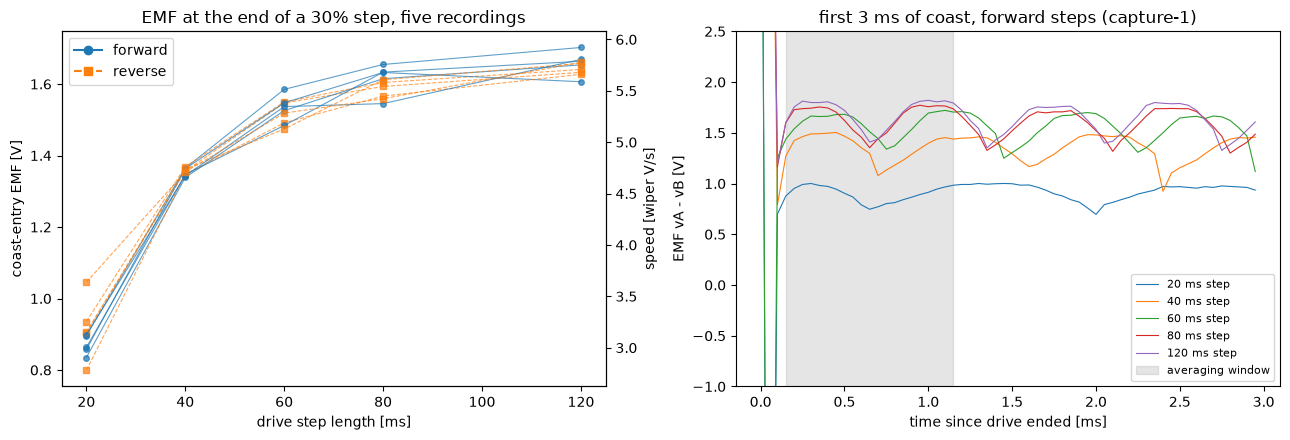

emf_V  emf_spread_pct  emf_sd_within_V  samples  omega_T  \
direction step_ms                                                             
forward   20       0.870           3.121            0.094     21.0    3.027   
          40       1.351           0.886            0.124     21.0    4.701   
          60       1.536           2.381            0.131     21.0    5.343   
          80       1.616           2.601            0.131     21.0    5.622   
          120      1.659           2.086            0.132     21.0    5.771   
reverse   20       0.918           9.600            0.118     21.0    3.193   
          40       1.358           0.575            0.099     21.0    4.723   
          60       1.516           2.209            0.124     21.0    5.274   
          80       1.587           1.472            0.133     21.0    5.520   
          120      1.644           0.913            0.143     20.8    5.719   

                   travel_V  
direction step_ms            
forward   20          0.008  
          40          0.095  
          60          0.182  
          80          0.285  
          120         0.517  
reverse   20          0.013  
          40          0.094  
          60          0.188  
          80          0.312  
          120         0.516

In [5]:
ENTRY_LO, ENTRY_HI = 3, 23   # coast samples averaged for the coast-entry EMF

def step_records(name, sweeps):
    out = []
    for ms in STEP_MS:
        df = sweeps[ms][0]
        vb, bias, rail = df["vb"].iloc[0], df["bias"].iloc[0], rail_V(df)
        for s in (1, 3):
            drv, co = df[df["seg"] == s], df[df["seg"] == s + 1]
            d = int(drv["dir"].iloc[0])
            vA, vB = term_V(co["vmotor_a"].to_numpy(), vb), term_V(co["vmotor_b"].to_numpy(), vb)
            e = (vA - vB) * d
            k = np.arange(len(e))
            sel = (k >= ENTRY_LO) & (k <= ENTRY_HI) & (vA + vB < rail)
            cur = (drv["current_raw"].to_numpy() - bias) * A_PER_COUNT
            ok = drv["window_valid"].to_numpy() == 1
            cur = pd.Series(np.where(ok, cur, np.nan)).ffill().bfill().to_numpy()
            p = drv["pos"].to_numpy() * V_ADC_PER_COUNT * d
            t = np.arange(len(p)) * DT
            out.append({
                "recording": name, "step_ms": ms, "dir": d, "T_s": len(p) * DT,
                "emf_V": e[sel].mean(), "emf_sd_V": e[sel].std(), "emf_n": int(sel.sum()),
                "omega_T": e[sel].mean() / K_E,
                "cur": cur, "pos": p, "emf_trace": e,
                "w0_pot": np.polyfit(t[:100], p[:100], 1)[0],       # first 5 ms
                "wT_pot": np.polyfit(t[-100:], p[-100:], 1)[0],     # last 5 ms
                "travel_V": p[-1] - p[0],
            })
    return out

step_list = sum((step_records(n, s) for n, s in steps_raw.items()), [])
steps = pd.DataFrame(step_list)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, g in steps.groupby("recording"):
    for d, mk in ((1, "-o"), (-1, "--s")):
        gg = g[g["dir"] == d].sort_values("step_ms")
        axes[0].plot(gg["step_ms"], gg["emf_V"], mk, ms=4, lw=0.8, alpha=0.7,
                     color="tab:blue" if d > 0 else "tab:orange")
axes[0].plot([], [], "-o", color="tab:blue", label="forward")
axes[0].plot([], [], "--s", color="tab:orange", label="reverse")
axes[0].set_xlabel("drive step length [ms]")
axes[0].set_ylabel("coast-entry EMF [V]")
axes[0].set_title("EMF at the end of a 30% step, five recordings")
axes[0].legend()
ax2 = axes[0].twinx()
ax2.set_ylim(np.array(axes[0].get_ylim()) / K_E)
ax2.set_ylabel("speed [wiper V/s]")
first = steps[(steps["recording"] == next(iter(steps_raw))) & (steps["dir"] == 1)]
for _, row in first.sort_values("step_ms").iterrows():
    e = row["emf_trace"][:60]
    axes[1].plot(np.arange(len(e)) * DT * 1e3, e, "-", lw=0.8, label=f"{row['step_ms']} ms step")
axes[1].axvspan(ENTRY_LO * DT * 1e3, ENTRY_HI * DT * 1e3, color="grey", alpha=0.2, label="averaging window")
axes[1].set_ylim(-1, 2.5)
axes[1].set_xlabel("time since drive ended [ms]")
axes[1].set_ylabel("EMF vA - vB [V]")
axes[1].set_title(f"first 3 ms of coast, forward steps ({first['recording'].iloc[0]})")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

DIRS = {1: "forward", -1: "reverse"}
entry = steps.assign(direction=steps["dir"].map(DIRS)).groupby(["direction", "step_ms"]).agg(
    emf_V=("emf_V", "mean"), emf_spread_pct=("emf_V", lambda s: s.std() / s.mean() * 100),
    emf_sd_within_V=("emf_sd_V", "mean"), samples=("emf_n", "mean"),
    omega_T=("omega_T", "mean"), travel_V=("travel_V", "mean"))
entry.round(3)


Findings:

- The coast-entry EMF rises from 0.87 V at 20 ms to 1.66 V at 120 ms
  forward (0.92 to 1.64 V reverse), which is 3.0 to 5.8 wiper V/s. The
  rise is steep between 20 and 40 ms and nearly flat from 80 to 120 ms,
  the shape of a first-order approach to a steady speed near 5.8 wiper
  V/s, which section 5.3 fits.
- The spread across the five recordings is under 3% at 40 ms and above.
  At 20 ms it is 3% forward and 10% reverse, the one step short enough
  for the entry speed to matter (section 5.3).
- The EMF in the averaging window is flat to within its ripple. The
  first two coast samples read the drive rail and the diode phase and
  are excluded by the mask, the third is the transition.

### 5.2 Drive current during the step

The current that accelerates the motor is the per-sample crest-scan shunt
reading of the drive step, bias subtracted. The figure shows it for the
five step lengths of one recording, forward. The table summarizes the
trace by step length, pooled over recordings and directions, and fits the
tail of the 60, 80 and 120 ms steps (from 10 ms in) with a single
exponential $i(t) = i_{ss} + A\,e^{-t/\tau_i}$, the form notebook 04 uses
on the duty grid.


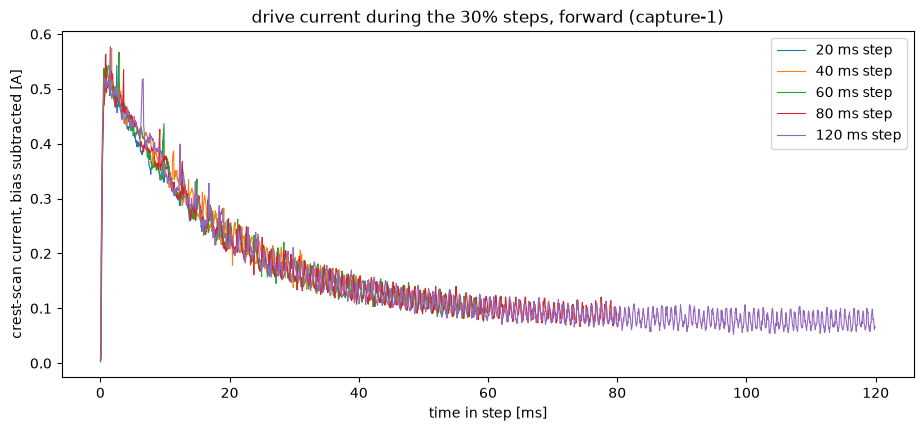

,i_at_0.5ms_A,i_peak_A,t_peak_ms,i_mean_A,i_last_2ms_A,peak_over_last,tail_i_ss_A,tail_tau_ms
step_ms,,,,,,,,
20,0.482,0.561,1.885,0.348,0.230,2.443,NaN,NaN
40,0.461,0.565,2.295,0.254,0.129,4.387,NaN,NaN
60,0.477,0.559,2.520,0.206,0.093,6.044,0.082,16.566
80,0.469,0.573,2.065,0.175,0.080,7.159,0.078,17.372
120,0.470,0.565,1.630,0.141,0.070,8.102,0.072,18.557


In [6]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for _, row in first.sort_values("step_ms").iterrows():
    ax.plot(np.arange(len(row["cur"])) * DT * 1e3, row["cur"], lw=0.8, label=f"{row['step_ms']} ms step")
ax.set_xlabel("time in step [ms]")
ax.set_ylabel("crest-scan current, bias subtracted [A]")
ax.set_title(f"drive current during the 30% steps, forward ({first['recording'].iloc[0]})")
ax.legend()
plt.show()

def i_model(t, i_ss, A, tau):
    return i_ss + A * np.exp(-t / tau)

TAIL_SKIP = 200   # 10 ms, excluded from the exponential fit of the current tail

rows = []
for _, row in steps.iterrows():
    c = row["cur"]
    r = {"step_ms": row["step_ms"], "i_at_0.5ms_A": c[10], "i_peak_A": c.max(),
         "t_peak_ms": int(c.argmax()) * DT * 1e3, "i_mean_A": c.mean(),
         "i_last_2ms_A": c[-40:].mean(), "peak_over_last": c.max() / c[-40:].mean()}
    if row["step_ms"] >= 60:
        t = np.arange(len(c) - TAIL_SKIP) * DT
        (i_ss, A, tau), _ = curve_fit(i_model, t, c[TAIL_SKIP:], p0=[c[-1], c[TAIL_SKIP] - c[-1], 0.02])
        r.update({"tail_i_ss_A": i_ss, "tail_tau_ms": tau * 1e3})
    rows.append(r)
current_tab = pd.DataFrame(rows).groupby("step_ms").mean()
current_tab.round(3)


Findings:

- The current rises from the bias to about 0.5 A within the first 0.5 ms
  of every step, the inductive rise against the winding, and peaks at
  0.56 to 0.57 A between 1.6 and 2.5 ms. In this window the motor is still moving
  backward from the repositioning move, and its EMF adds to the applied
  voltage.
- From there the current falls as the motor reverses and speeds up, to
  0.23 A at the end of the 20 ms step and 0.07 A at the end of the 120 ms
  step, a factor of 2.4 to 8.1 from peak to end. The step-mean current
  falls from 0.35 A at 20 ms to 0.14 A at 120 ms. A model that drives the
  inertia with the mean current is therefore wrong by design, and section
  5.3 shows by how much.
- The tail of the long steps follows one exponential with $\tau_i$ of
  16.6 to 18.6 ms toward a floor of 0.07 to 0.08 A, the same time constant
  notebook 04 reads on the duty grid. The floor is the steady drive
  current at 30% duty, the friction current at that speed.

### 5.3 Route A, the rise curve fitted with the measured current

The equation of the purpose section is integrated over every step with
the measured current trace,

$$\omega(T) = \omega_0 + \frac{1}{J_i}\int_0^T \big(i(t) - i_c\,\mathrm{sign}\,\omega(t) - i_v\,\omega(t)\big)\,dt ,$$

by forward Euler at the sample rate, and $\omega(T)$ is matched to the
coast-entry speed of the step. The unknowns per recording are $J_i$ and
one entry speed $\omega_0$ per direction, three parameters for ten
measured speeds, on the premise that the repositioning move leaves the
mechanism at about the same speed before every step of a direction. The
fit weighs all ten speeds equally.

The friction line $i = i_c + i_v\,\omega$ per direction comes from the
duty grid with the method of notebook 04, recomputed here so the numbers
are traceable within this notebook. For each grid step at or above 15%
duty, the current after the first 10 ms is fitted with the exponential of
section 5.2 to extrapolate the steady current, and the position over the
same window is fitted with the matching first-order trajectory to
extrapolate the steady speed. The line is fitted through the steps whose
steady speed is at or below 10.5 wiper V/s, the range the coast segments
cover.


In [7]:
GRID_SKIP = 200     # first 10 ms of each grid step excluded from the extrapolation
V_MATCH = 10.5      # wiper V/s, the ceiling of the coast entry speeds

def grid_steps(name, df):
    out = []
    for seg_id, seg in df[(df["seg"] > 0) & (df["mag_pct"] >= 15)].groupby("seg"):
        d = np.sign(seg["duty_pct"].iloc[0])
        p = seg["pos"].to_numpy() * V_ADC_PER_COUNT * d
        cur = (seg["current_raw"].to_numpy() - seg["bias"].iloc[0]) * A_PER_COUNT
        ok = seg["window_valid"].to_numpy() == 1
        t = np.arange(len(p) - GRID_SKIP) * DT
        c, tc = cur[GRID_SKIP:][ok[GRID_SKIP:]], t[ok[GRID_SKIP:]]
        (i_ss, A, tau), _ = curve_fit(i_model, tc, c, p0=[c[-1], c[0] - c[-1], 0.02],
                                      bounds=([0, -np.inf, 0.002], [np.inf, np.inf, 0.5]))
        g = tau * (1 - np.exp(-t / tau))
        X = np.column_stack([np.ones_like(t), t - g, g])
        p0, v_ss, v0 = np.linalg.lstsq(X, p[GRID_SKIP:], rcond=None)[0]
        out.append({"recording": name, "mag_pct": int(round(abs(seg["duty_pct"].iloc[0]))),
                    "dir": int(d), "v_ss": v_ss, "i_ss": i_ss, "tau_ms": tau * 1e3})
    return out

grid = pd.DataFrame(sum((grid_steps(n, df) for n, df in grid_raw.items()), []))
I_C, I_V = {}, {}
rows = []
for d, label in DIRS.items():
    g = grid[(grid["dir"] == d) & (grid["v_ss"] <= V_MATCH)]
    k = np.polyfit(g["v_ss"], g["i_ss"], 1)
    I_C[d], I_V[d] = k[1], k[0]
    per = np.array([np.polyfit(gg["v_ss"], gg["i_ss"], 1) for _, gg in g.groupby("recording")])
    rows.append({"direction": label, "steps": len(g), "i_c [A]": k[1], "i_v [A per wiper V/s]": k[0],
                 "i_c / i_v [wiper V/s]": k[1] / k[0],
                 "i_c per-recording cv [%]": per[:, 1].std() / per[:, 1].mean() * 100,
                 "i_v per-recording cv [%]": per[:, 0].std() / per[:, 0].mean() * 100,
                 "grid tau_i [ms]": g["tau_ms"].mean()})
friction = pd.DataFrame(rows).set_index("direction")
friction.round(4)


,steps,i_c [A],i_v [A per wiper V/s],i_c / i_v [wiper V/s],i_c per-recording cv [%],i_v per-recording cv [%],grid tau_i [ms]
direction,,,,,,,
forward,80,0.0447,0.0053,8.3891,4.7212,7.8354,18.1618
reverse,80,0.0351,0.0056,6.2306,7.2921,5.5613,18.4078


The line gives $i_c$ of 0.0447 A forward and 0.0351 A reverse and $i_v$
of 0.0053 and 0.0056 A per wiper V/s, from 80 grid steps per direction,
with per-recording spreads of 5 to 8% on both constants. Its ratio
$i_c / i_v$ is 8.4 wiper V/s forward and 6.2 reverse, against 11.5 from
the coast fit of section 5.1. Section 6 returns to that difference.

The route A fit follows. The figure shows, for one recording, the
integrated speed trajectory of every step with the fitted $J_i$ and entry
speeds, and the measured coast-entry speed at the end of each step. The
table gives the fit per recording, with $J_i$ refitted per direction
(five speeds, two parameters) as a check of the shared value.


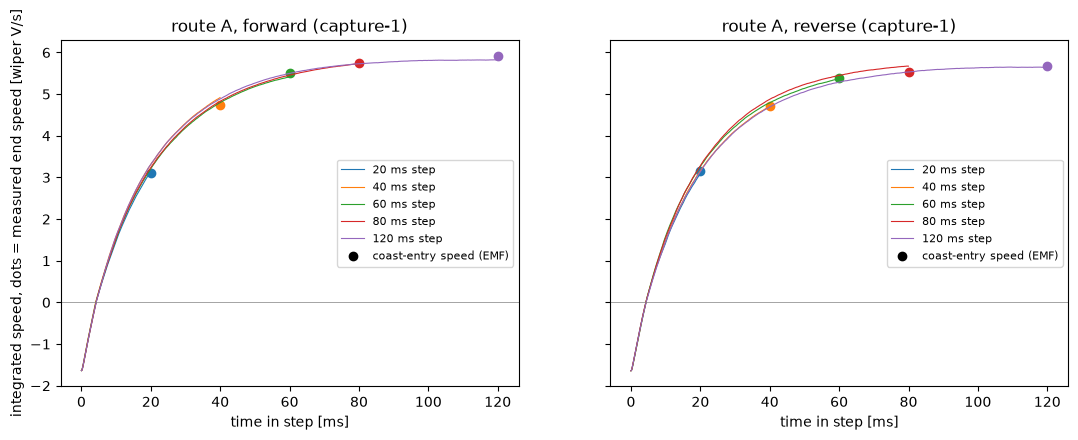

,J_i [A per wiper V/s2],omega_0 forward [wiper V/s],omega_0 reverse [wiper V/s],rms residual [wiper V/s],J_i forward only,J_i reverse only
capture-1,0.00132,-1.63955,-1.64286,0.08395,0.00127,0.00137
capture-2,0.00120,-2.45272,-2.21979,0.06961,0.00119,0.00128
capture-3,0.00115,-2.90826,-2.97452,0.16212,0.00127,0.00111
capture-4,0.00125,-2.11383,-2.04353,0.22058,0.00114,0.00136
capture-5,0.00130,-1.70420,-1.39482,0.16590,0.00121,0.00145
mean,0.00124,-2.16371,-2.05510,0.14043,0.00122,0.00131
min,0.00115,-2.90826,-2.97452,0.06961,0.00114,0.00111
max,0.00132,-1.63955,-1.39482,0.22058,0.00127,0.00145
cv [%],5.88117,24.52395,29.58322,44.68199,4.36412,9.64746


In [8]:
def integrate(cur, w0, Ji, ic, iv):
    # Forward Euler of Ji dw/dt = i - ic sign(w) - iv w at the sample rate.
    w = np.empty(len(cur))
    x = w0
    for k in range(len(cur)):
        x = x + DT * (cur[k] - ic * np.sign(x) - iv * x) / Ji
        w[k] = x
    return w

def route_a(sub, ic, iv, current="trace", w0_from=None, dirs=(1, -1)):
    # Ji shared over the steps of `sub`, one entry speed per direction unless
    # w0_from names a column that supplies it per step.
    def per_step(x):
        Ji, w0 = x[0], {1: x[1], -1: x[2]}
        rows = []
        for _, row in sub.iterrows():
            cur = row["cur"] if current == "trace" else np.full(len(row["cur"]), row["cur"].mean())
            start = row[w0_from] if w0_from else w0[row["dir"]]
            w = integrate(cur, start, Ji, ic[row["dir"]], iv[row["dir"]])
            rows.append({"recording": row["recording"], "dir": row["dir"], "step_ms": row["step_ms"],
                         "omega_T": row["omega_T"], "omega_fit": w[-1], "travel_V": row["travel_V"],
                         "travel_fit_V": np.sum(w) * DT})
        return pd.DataFrame(rows)
    def resid(x):
        tab = per_step(x)
        return (tab["omega_fit"] - tab["omega_T"]).to_numpy()
    res = least_squares(resid, [0.0012, -2.0, -2.0], bounds=([1e-5, -20, -20], [1, 20, 20]))
    tab = per_step(res.x)
    return {"Ji": res.x[0], "w0": {1: res.x[1], -1: res.x[2]},
            "rms": np.sqrt(np.mean(res.fun ** 2)), "steps": tab}

fits_a = {}
rows = []
for name, sub in steps.groupby("recording"):
    f = route_a(sub, I_C, I_V)
    f["fwd"] = route_a(sub[sub["dir"] == 1], I_C, I_V)
    f["rev"] = route_a(sub[sub["dir"] == -1], I_C, I_V)
    fits_a[name] = f
    rows.append({"recording": name, "J_i [A per wiper V/s2]": f["Ji"],
                 "omega_0 forward [wiper V/s]": f["w0"][1], "omega_0 reverse [wiper V/s]": f["w0"][-1],
                 "rms residual [wiper V/s]": f["rms"],
                 "J_i forward only": f["fwd"]["Ji"], "J_i reverse only": f["rev"]["Ji"]})
route_a_tab = pd.DataFrame(rows).set_index("recording")
J_A = route_a_tab["J_i [A per wiper V/s2]"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
name = next(iter(fits_a))
f = fits_a[name]
for ax, d in zip(axes, (1, -1)):
    sub = steps[(steps["recording"] == name) & (steps["dir"] == d)].sort_values("step_ms")
    for _, row in sub.iterrows():
        w = integrate(row["cur"], f["w0"][d], f["Ji"], I_C[d], I_V[d])
        line, = ax.plot(np.arange(len(w)) * DT * 1e3, w, lw=0.8, label=f"{row['step_ms']} ms step")
        ax.plot(row["T_s"] * 1e3, row["omega_T"], "o", color=line.get_color(), ms=6)
    ax.plot([], [], "ko", label="coast-entry speed (EMF)")
    ax.axhline(0, color="grey", lw=0.5)
    ax.set_xlabel("time in step [ms]")
    ax.set_title(f"route A, {DIRS[d]} ({name})")
    ax.legend(fontsize=8)
axes[0].set_ylabel("integrated speed, dots = measured end speed [wiper V/s]")
plt.show()

with_summary(route_a_tab).round(5)


The per-step residuals of the shared fit, pooled over recordings:


In [9]:
resid_tab = pd.concat([f["steps"] for f in fits_a.values()])
resid_tab["residual"] = resid_tab["omega_fit"] - resid_tab["omega_T"]
resid_tab["residual_pct"] = resid_tab["residual"] / resid_tab["omega_T"] * 100
(resid_tab.assign(direction=resid_tab["dir"].map(DIRS))
    .groupby(["direction", "step_ms"])[["omega_T", "omega_fit", "residual", "residual_pct", "travel_V", "travel_fit_V"]]
    .mean().round(3))


omega_T  omega_fit  residual  residual_pct  travel_V  \
direction step_ms                                                         
forward   20         3.027      3.108     0.081         2.697     0.008   
          40         4.701      4.704     0.003         0.063     0.095   
          60         5.343      5.373     0.031         0.618     0.182   
          80         5.622      5.570    -0.052        -0.911     0.285   
          120        5.771      5.673    -0.098        -1.662     0.517   
reverse   20         3.193      3.131    -0.062        -1.624     0.013   
          40         4.723      4.700    -0.024        -0.501     0.094   
          60         5.274      5.381     0.107         2.066     0.188   
          80         5.520      5.615     0.094         1.721     0.312   
          120        5.719      5.599    -0.119        -2.074     0.516   

                   travel_fit_V  
direction step_ms                
forward   20              0.020  
          40              0.100  
          60              0.203  
          80              0.310  
          120             0.538  
reverse   20              0.021  
          40              0.101  
          60              0.206  
          80              0.315  
          120             0.532

Findings:

- $J_i$ is 0.00124 A per wiper V/s$^2$ on average, 0.00115 to 0.00132
  across the five recordings, a spread of 6%. The fitted entry speeds are
  -1.4 to -3.0 wiper V/s, the residual reverse motion from the
  repositioning move, and they come out nearly equal for the two
  directions of a recording.
- The fit reproduces the ten speeds of a recording with an rms residual of
  0.07 to 0.22 wiper V/s, 1 to 4% of the measured speeds. The residual
  has a shape. The 120 ms step comes out 0.10 to 0.12 wiper V/s slow in
  both directions and the reverse 60 and 80 ms steps 0.09 to 0.11 fast,
  so the model approaches the steady speed a little later than the
  mechanism does. The model's travel exceeds the pot's by 0.003 to
  0.025 wiper V in every step of both directions. *Hypothesis (not tested here): both
  signatures fit a friction line whose Coulomb term is a little larger
  and whose viscous term a little smaller than the drive-side line, the
  direction in which the coast fit of section 5.1 differs from it.*
- Refitted per direction, $J_i$ is 0.00122 forward (0.00114 to 0.00127)
  and 0.00131 reverse (0.00111 to 0.00145). The two overlap, and the
  reverse spread is twice the forward, following the reverse 20 ms step
  of section 5.1.

The next table tests the modeling choices. The mean-current variant
replaces the trace with its step mean. The coast-friction variant replaces
the drive-side line with the coast friction of section 5.1 scaled by
$J_i$ itself, $i_c = J_i a$ and $i_v = J_i b$, which makes route A
independent of the duty grid. The pot variant fixes the entry speed of
every step at the slope of the pot over its first 5 ms.


In [10]:
def route_a_coast(sub, a, b):
    # Friction from the coast fit, scaled by the Ji being fitted.
    def resid(x):
        Ji, w0 = x[0], {1: x[1], -1: x[2]}
        return np.array([integrate(row["cur"], w0[row["dir"]], Ji, Ji * a, Ji * b)[-1] - row["omega_T"]
                         for _, row in sub.iterrows()])
    res = least_squares(resid, [0.0012, -2.0, -2.0], bounds=([1e-5, -20, -20], [1, 20, 20]))
    return {"Ji": res.x[0], "rms": np.sqrt(np.mean(res.fun ** 2))}

variants = {"measured current, entry speed fitted (route A)": {n: f for n, f in fits_a.items()}}
variants["step-mean current, entry speed fitted"] = {
    n: route_a(sub, I_C, I_V, current="mean") for n, sub in steps.groupby("recording")}
variants["measured current, coast friction scaled by J_i"] = {
    n: route_a_coast(sub, A_COAST.mean(), B_COAST.mean()) for n, sub in steps.groupby("recording")}
variants["measured current, entry speed from the pot"] = {
    n: route_a(sub, I_C, I_V, w0_from="w0_pot") for n, sub in steps.groupby("recording")}

rows = []
for label, fs in variants.items():
    j = pd.Series({n: f["Ji"] for n, f in fs.items()})
    rows.append({"variant": label, "J_i mean": j.mean(), "min": j.min(), "max": j.max(),
                 "cv [%]": j.std() / j.mean() * 100, "vs route A [%]": (j.mean() / J_A.mean() - 1) * 100,
                 "rms residual [wiper V/s]": np.mean([f["rms"] for f in fs.values()])})
J_A_COAST = pd.Series({n: f["Ji"] for n, f in variants["measured current, coast friction scaled by J_i"].items()})
variant_tab = pd.DataFrame(rows).set_index("variant")
variant_tab.round(5)


,J_i mean,min,max,cv [%],vs route A [%],rms residual [wiper V/s]
variant,,,,,,
"measured current, entry speed fitted (route A)",0.00124,0.00115,0.00132,5.88117,0.00000,0.14043
"step-mean current, entry speed fitted",0.00163,0.00160,0.00168,2.06890,31.21830,0.17032
"measured current, coast friction scaled by J_i",0.00131,0.00129,0.00135,1.54602,5.64456,0.15047
"measured current, entry speed from the pot",0.00122,0.00116,0.00127,3.79013,-1.73589,0.50890


Findings:

- The step-mean current inflates $J_i$ by 31%, because the mean spreads
  the early current peak over the whole step and the model then needs
  more inertia to end at the same speed. The residual (0.17 against
  0.14 wiper V/s) does not flag the error, since the fitted entry speeds
  absorb it. The per-sample trace is required.
- With the coast friction in place of the drive-side line, $J_i$ is
  0.00131 (0.00129 to 0.00135), 6% above route A with a 2% spread. The
  friction line moves the answer by 6%, since friction is a small part of
  the current in the short steps that set the curvature of the rise.
- Fixing the entry speed from the pot raises the residual to 0.51 wiper
  V/s. The mean $J_i$ moves only 2%, because the pot's error averages
  out over the five steps of a direction, but the per-recording values
  of 0.00116 to 0.00127 with a 4% spread owe nothing to the fit quality.
  The entry speed has to be fitted (section 7 quantifies the pot's
  problem).

Two model-free cross-checks follow. The first fits the five coast-entry
speeds of each recording and direction with an exponential approach,
$\omega(T) = \omega_{ss} - (\omega_{ss} - \omega_0)\,e^{-T/\tau}$, with no
current and no friction in it. Its time constant is compared with the one
the fitted constants imply. Under constant applied voltage the current
falls with speed at a rate $k_i = -di/d\omega$, read here from the current
at the end of each step against the speed at the end of each step, and
the linearized equation gives the rise time constant $\tau = J_i / (k_i +
i_v)$. The friction-only constant $J_i / i_v$, the time constant of a coast
in the viscous regime, is listed for reference.

The second is the initial-slope estimate from the 20 ms step alone,
$J_i = \int (i - i_c\,\mathrm{sign}\,\omega - i_v\,\omega)\,dt \,/\,
(\omega_T - \omega_0)$, with the friction evaluated on a straight ramp
from $\omega_0$ to $\omega_T$ and $\omega_0$ taken from the pot's first
5 ms, the only entry speed that is measured on its own.


In [11]:
def rise(T, wss, w0, tau):
    return wss - (wss - w0) * np.exp(-T / tau)

rows = []
for (name, d), sub in steps.groupby(["recording", "dir"]):
    (wss, w0, tau), _ = curve_fit(rise, sub["T_s"], sub["omega_T"], p0=[6.0, -3.0, 0.02])
    i_end = np.array([row["cur"][-40:].mean() for _, row in sub.iterrows()])
    k_i = -np.polyfit(sub["omega_T"], i_end, 1)[0]
    Ji = fits_a[name]["Ji"]
    rows.append({"recording": name, "direction": DIRS[d],
                 "omega_ss, exponential [wiper V/s]": wss, "omega_0, exponential [wiper V/s]": w0,
                 "tau, exponential [ms]": tau * 1e3,
                 "k_i = -di/domega [A per wiper V/s]": k_i,
                 "tau = J_i / (k_i + i_v) [ms]": Ji / (k_i + I_V[d]) * 1e3,
                 "J_i / i_v [ms]": Ji / I_V[d] * 1e3})
tau_tab = pd.DataFrame(rows).set_index(["recording", "direction"])
TAU_EXP = tau_tab["tau, exponential [ms]"]
with_summary(tau_tab).round(3)


omega_ss, exponential [wiper V/s]  \
recording direction                                      
capture-1 reverse                                5.700   
          forward                                5.970   
capture-2 reverse                                5.733   
          forward                                5.781   
capture-3 reverse                                5.609   
          forward                                5.680   
capture-4 reverse                                5.786   
          forward                                5.835   
capture-5 reverse                                5.813   
          forward                                5.743   
mean                                             5.765   
min                                              5.609   
max                                              5.970   
cv [%]                                           1.707   

                     omega_0, exponential [wiper V/s]  tau, exponential [ms]  \
recording direction                                                            
capture-1 reverse                              -1.131                 20.380   
          forward                              -0.880                 22.877   
capture-2 reverse                              -0.710                 20.960   
          forward                              -1.487                 21.560   
capture-3 reverse                              -2.457                 19.016   
          forward                              -2.401                 18.264   
capture-4 reverse                              -0.148                 24.398   
          forward                              -0.642                 24.041   
capture-5 reverse                               1.601                 30.126   
          forward                              -0.466                 23.041   
mean                                           -0.872                 22.466   
min                                            -2.457                 18.264   
max                                             1.601                 30.126   
cv [%]                                        133.373                 15.013   

                     k_i = -di/domega [A per wiper V/s]  \
recording direction                                       
capture-1 reverse                                 0.063   
          forward                                 0.055   
capture-2 reverse                                 0.064   
          forward                                 0.055   
capture-3 reverse                                 0.057   
          forward                                 0.060   
capture-4 reverse                                 0.056   
          forward                                 0.059   
capture-5 reverse                                 0.077   
          forward                                 0.065   
mean                                              0.061   
min                                               0.055   
max                                               0.077   
cv [%]                                           10.861   

                     tau = J_i / (k_i + i_v) [ms]  J_i / i_v [ms]  
recording direction                                                
capture-1 reverse                          19.228         234.570  
          forward                          21.761         248.298  
capture-2 reverse                          17.265         212.647  
          forward                          19.966         225.091  
capture-3 reverse                          18.321         203.167  
          forward                          17.511         215.056  
capture-4 reverse                          20.312         221.209  
          forward                          19.321         234.155  
capture-5 reverse                          15.822         231.099  
          forward                          18.439         244.622  
mean                                       18.795 

In [12]:
rows = []
for _, row in steps[steps["step_ms"] == 20].iterrows():
    d = row["dir"]
    ramp = np.linspace(row["w0_pot"], row["omega_T"], len(row["cur"]))
    net = np.sum(row["cur"] - I_C[d] * np.sign(ramp) - I_V[d] * ramp) * DT
    rows.append({"recording": row["recording"], "direction": DIRS[d],
                 "omega_0, pot 5 ms [wiper V/s]": row["w0_pot"], "omega_T [wiper V/s]": row["omega_T"],
                 "net current integral [A s]": net,
                 "J_i, initial slope": net / (row["omega_T"] - row["w0_pot"])})
slope_tab = pd.DataFrame(rows).set_index(["recording", "direction"])
J_SLOPE = slope_tab["J_i, initial slope"]
with_summary(slope_tab).round(5)


omega_0, pot 5 ms [wiper V/s]  omega_T [wiper V/s]  \
recording direction                                                       
capture-1 forward                         -1.05836              3.11778   
          reverse                         -2.15095              3.14261   
capture-2 forward                         -1.04444              2.90438   
          reverse                         -1.78131              3.25431   
capture-3 forward                         -0.65923              2.98325   
          reverse                         -2.83870              2.77986   
capture-4 forward                         -1.23927              3.00287   
          reverse                         -2.28641              3.15182   
capture-5 forward                         -2.28061              3.12659   
          reverse                         -2.19707              3.63708   
mean                                      -1.75364              3.11006   
min                                       -2.83870              2.77986   
max                                       -0.65923              3.63708   
cv [%]                                    40.51389              7.43024   

                     net current integral [A s]  J_i, initial slope  
recording direction                                                  
capture-1 forward                       0.00640             0.00153  
          reverse                       0.00660             0.00125  
capture-2 forward                       0.00647             0.00164  
          reverse                       0.00661             0.00131  
capture-3 forward                       0.00649             0.00178  
          reverse                       0.00706             0.00126  
capture-4 forward                       0.00667             0.00157  
          reverse                       0.00663             0.00122  
capture-5 forward                       0.00685             0.00127  
          reverse                       0.00663             0.00114  
mean                                    0.00664             0.00140  
min                                     0.00640             0.00114  
max                                     0.00706             0.00178  
cv [%]                                  2.88659            15.49169

Findings:

- The exponential approach puts the steady speed at 5.6 to 6.0 wiper V/s
  and the time constant at 22.5 ms on average, 18 to 30 ms across the ten
  fits, with the entry speed as a third free parameter on five points.
  The fitted constants imply 16 to 22 ms (18.8 on average) from
  $J_i / (k_i + i_v)$, with $k_i$ of 0.055 to 0.077 A per wiper V/s, and
  the current tails of section 5.2 read 16.6 to 18.6 ms. The three agree
  on a rise time constant near 20 ms. The exponential is the loosest of the three, since
  the first 3 ms of every step (the current peak and the sign change of
  the Coulomb term) are not exponential and the 20 ms point carries them.
- The friction-only time constant $J_i / i_v$ is 0.20 to 0.25 s, about
  twelve times the rise constant. Under voltage drive the back-EMF, through
  $k_i$, is what sets the rise, and mechanical friction adds less than a
  tenth of the damping.
- The initial-slope estimate gives 0.00140 A per wiper V/s$^2$ on average
  (0.00114 to 0.00178), 12% above route A with a 15% spread, and its
  spread follows the pot-derived entry speed one to one, since the net
  current integral has a 3% spread across the ten steps. It
  confirms the order of magnitude and the sign of the entry-speed
  problem.

## 6. Route B, coast deceleration and the friction line

Coast decelerates the mechanism under friction alone, so by the equation
of the purpose section with $i = 0$, the coast constants of section 5.1
are the friction constants divided by the inertia, $a = i_c / J_i$ and
$b = i_v / J_i$. Each friction term therefore gives its own estimate,

$$J_i = \frac{i_c}{a}, \qquad J_i = \frac{i_v}{b},$$

with $i_c$ and $i_v$ from the drive-side line of section 5.3 (mean of the
two directions, and per direction) and $a$, $b$ from the coast fit of the
same recording. The table gives both per spin-down recording. A second
table converts the coast constants into current units with the route A
inertia, $J_i a$ and $J_i b$, and sets them beside the drive-side line.


In [13]:
ic_mean, iv_mean = np.mean(list(I_C.values())), np.mean(list(I_V.values()))
route_b_tab = pd.DataFrame({
    "a [wiper V/s2]": A_COAST, "b [1/s]": B_COAST,
    "J_i = i_c / a": ic_mean / A_COAST, "J_i = i_v / b": iv_mean / B_COAST,
    "J_i = i_c / a, forward": I_C[1] / A_COAST, "J_i = i_c / a, reverse": I_C[-1] / A_COAST,
    "J_i = i_v / b, forward": I_V[1] / B_COAST, "J_i = i_v / b, reverse": I_V[-1] / B_COAST,
})
J_B_C, J_B_V = route_b_tab["J_i = i_c / a"], route_b_tab["J_i = i_v / b"]
with_summary(route_b_tab).round(5)


,a [wiper V/s2],b [1/s],J_i = i_c / a,J_i = i_v / b,"J_i = i_c / a, forward","J_i = i_c / a, reverse","J_i = i_v / b, forward","J_i = i_v / b, reverse"
capture-1,33.85129,3.03610,0.00118,0.00181,0.00132,0.00104,0.00175,0.00186
capture-2,37.51884,2.78889,0.00106,0.00197,0.00119,0.00094,0.00191,0.00202
capture-3,33.24570,2.99844,0.00120,0.00183,0.00134,0.00106,0.00178,0.00188
capture-4,34.35140,2.95804,0.00116,0.00185,0.00130,0.00102,0.00180,0.00191
capture-5,32.85593,3.23346,0.00121,0.00170,0.00136,0.00107,0.00165,0.00174
mean,34.36463,3.00298,0.00116,0.00183,0.00130,0.00102,0.00178,0.00188
min,32.85593,2.78889,0.00106,0.00170,0.00119,0.00094,0.00165,0.00174
max,37.51884,3.23346,0.00121,0.00197,0.00136,0.00107,0.00191,0.00202
cv [%],5.39344,5.32000,5.11576,5.30316,5.11576,5.11576,5.30316,5.30316


In [14]:
coast_i = {"Coulomb [A]": J_A.mean() * A_COAST.mean(),
           "viscous [A per wiper V/s]": J_A.mean() * B_COAST.mean(),
           "Coulomb / viscous [wiper V/s]": A_COAST.mean() / B_COAST.mean()}
drive_i = {"Coulomb [A]": (I_C[1], I_C[-1], ic_mean),
           "viscous [A per wiper V/s]": (I_V[1], I_V[-1], iv_mean),
           "Coulomb / viscous [wiper V/s]": (I_C[1] / I_V[1], I_C[-1] / I_V[-1], ic_mean / iv_mean)}
pd.DataFrame([
    {"term": term, "coast, scaled by route A J_i": coast_i[term],
     "drive line, forward": drive_i[term][0], "drive line, reverse": drive_i[term][1],
     "drive line, mean": drive_i[term][2],
     "coast vs drive mean [%]": (coast_i[term] / drive_i[term][2] - 1) * 100}
    for term in coast_i
]).set_index("term").round(4)


,"coast, scaled by route A J_i","drive line, forward","drive line, reverse","drive line, mean",coast vs drive mean [%]
term,,,,,
Coulomb [A],0.0427,0.0447,0.0351,0.0399,7.0749
viscous [A per wiper V/s],0.0037,0.0053,0.0056,0.0055,-31.8899
Coulomb / viscous [wiper V/s],11.4435,8.3891,6.2306,7.2792,57.2086


Findings:

- The Coulomb route gives $J_i$ of 0.00116 A per wiper V/s$^2$ (0.00106
  to 0.00121 across the spin-down recordings, a 5% spread), 6% below
  route A. Per direction it is 0.00130 forward and 0.00102 reverse, the
  25% asymmetry of the drive-side Coulomb term carried through, since the
  coast fit has one $a$ for both directions.
- The viscous route gives 0.00183 (0.00170 to 0.00197), 47% above route
  A. The two routes disagree by 57% with each other, far outside their
  spreads, so the coast and the drive side do not agree on the viscous
  term. In current units the coast viscous term is 0.0037 A per wiper V/s
  against 0.0055 from the drive line, while the Coulomb terms agree
  within 7%. The ratio $a / b$ of 11.4 wiper V/s against $i_c / i_v$ of
  7.3 says the same thing.
- Route B is the weaker measurement by construction. It is a quotient of
  two fitted constants, each with its own 5 to 8% spread, and the viscous
  variant compounds the smallest term of the coast fit with the smallest
  term of the drive line. Route A uses the friction line only as a
  correction to the current, and section 5.3 showed that swapping the
  line for the coast friction moves it by 6%.
- What is and is not independent. Route A and the Coulomb variant of
  route B share the drive-side line as input, so their 7% agreement
  tests the coast fit's $a$ against the step data, with the line in
  common. The coast-friction variant of route A (0.00131) uses the coast
  fit in place of the line and agrees with the Coulomb variant of route B
  within 13%, with the coast fit in common and the line dropped. No pair
  of estimates here is free of shared input, and the one input that
  moves an estimate by more than 10% is the viscous term.
- *Hypothesis (not tested here): the drive-side viscous term is inflated
  by an electrical contribution to the steady drive current that grows
  with speed, which notebook 04 raises from the shape of its own line
  above 12 wiper V/s. Under that reading the coast $b$ is the mechanical
  viscous friction, $J_i b$ its value in current units, and the viscous
  route B is the one estimate here that should be set aside.*

## 7. Agreement and repeatability

The table collects every estimate of $J_i$ with its spread across
recordings and its difference from route A. The pairwise differences
follow, then the verdict, then the comparison of the two speed signals
that decides which route works.


In [15]:
def summary(label, s, note):
    return {"estimate": label, "J_i mean [A per wiper V/s2]": s.mean(), "min": s.min(), "max": s.max(),
            "cv [%]": s.std() / s.mean() * 100, "recordings": len(s),
            "vs route A [%]": (s.mean() / J_A.mean() - 1) * 100, "inputs": note}

estimates = pd.DataFrame([
    summary("route A, rise curve", J_A, "steps, drive-side friction line"),
    summary("route A, coast friction variant", J_A_COAST, "steps, coast fit"),
    summary("initial slope, 20 ms step", J_SLOPE, "20 ms steps, pot entry speed, drive-side line"),
    summary("route B, Coulomb, i_c / a", J_B_C, "coast fit a, drive-side line"),
    summary("route B, viscous, i_v / b", J_B_V, "coast fit b, drive-side line"),
]).set_index("estimate")
pd.set_option("display.max_colwidth", 60)
estimates.round(5)


,J_i mean [A per wiper V/s2],min,max,cv [%],recordings,vs route A [%],inputs
estimate,,,,,,,
"route A, rise curve",0.00124,0.00115,0.00132,5.88117,5,0.00000,"steps, drive-side friction line"
"route A, coast friction variant",0.00131,0.00129,0.00135,1.54602,5,5.64456,"steps, coast fit"
"initial slope, 20 ms step",0.00140,0.00114,0.00178,15.49169,10,12.33271,"20 ms steps, pot entry speed, drive-side line"
"route B, Coulomb, i_c / a",0.00116,0.00106,0.00121,5.11576,5,-6.40094,"coast fit a, drive-side line"
"route B, viscous, i_v / b",0.00183,0.00170,0.00197,5.30316,5,47.15278,"coast fit b, drive-side line"


In [16]:
names = estimates.index.tolist()
means = estimates["J_i mean [A per wiper V/s2]"]
pairs = pd.DataFrame([[(means[r] / means[c] - 1) * 100 for c in names] for r in names],
                     index=names, columns=names)
pairs.round(1)


,"route A, rise curve","route A, coast friction variant","initial slope, 20 ms step","route B, Coulomb, i_c / a","route B, viscous, i_v / b"
"route A, rise curve",0.0,-5.3,-11.0,6.8,-32.0
"route A, coast friction variant",5.6,0.0,-6.0,12.9,-28.2
"initial slope, 20 ms step",12.3,6.3,0.0,20.0,-23.7
"route B, Coulomb, i_c / a",-6.4,-11.4,-16.7,0.0,-36.4
"route B, viscous, i_v / b",47.2,39.3,31.0,57.2,0.0


Verdict:

- Route A stands as the inertia measurement of this notebook, $J_i =
  0.00124$ A per wiper V/s$^2$ with a 6% spread across five recordings.
  Its coast-friction variant (0.00131) and the Coulomb route B (0.00116)
  bracket it at +6% and -6%, each with a spread of 2 to 5%, and the
  initial-slope check lands within 12%. Three routes through three
  different subsets of the data agree within 13% of one another, which
  is the agreement this notebook can claim.
- The viscous route B (0.00183) is the one estimate outside that
  bracket, 47% above route A, and section 6 traces it to a viscous term
  that the coast and the drive side measure differently. It is
  reported and set aside.
- The implied mechanical rise time constant under 30% drive is near
  20 ms by three readings (section 5.3), and the friction-only constant
  $J_i / i_v$ is about 0.23 s.

The last table shows why the coast EMF is the speed signal for this
measurement. The rise curve needs the speed at the end of a 20 or 40 ms
step. From the pot that speed is a slope over the last 5 ms of the step,
and the acceleration over the step is the difference of two such slopes
divided by the step length. From the EMF it is a 1 ms average with the
pot ripple absent. The table compares the spread of each across the ten
steps of a length (five recordings, two directions).


In [17]:
def cv(s):
    return np.std(s) / abs(np.mean(s)) * 100

rows = []
for ms in (20, 40):
    sub = steps[steps["step_ms"] == ms]
    acc_pot = (sub["wT_pot"] - sub["w0_pot"]) / sub["T_s"]
    acc_quad = np.array([2 * np.polyfit(np.arange(len(row["pos"])) * DT, row["pos"], 2)[0]
                         for _, row in sub.iterrows()])
    w0_fit = np.array([fits_a[row["recording"]]["w0"][row["dir"]] for _, row in sub.iterrows()])
    acc_emf = (sub["omega_T"] - w0_fit) / sub["T_s"]
    for label, s in [("end speed, pot last 5 ms [wiper V/s]", sub["wT_pot"]),
                     ("end speed, EMF [wiper V/s]", sub["omega_T"]),
                     ("entry speed, pot first 5 ms [wiper V/s]", sub["w0_pot"]),
                     ("acceleration, pot end minus start [wiper V/s2]", acc_pot),
                     ("acceleration, pot quadratic fit [wiper V/s2]", acc_quad),
                     ("acceleration, EMF end minus fitted entry [wiper V/s2]", acc_emf)]:
        rows.append({"quantity": label, "step": f"{ms} ms", "mean": np.mean(s), "cv [%]": cv(s)})
signal_tab = pd.DataFrame(rows).set_index(["quantity", "step"]).unstack("step")
signal_tab.round(2)


mean         cv [%]  \
step                                                    20 ms   40 ms  20 ms   
quantity                                                                       
acceleration, EMF end minus fitted entry [wiper V/s2]  260.97  170.54   7.22   
acceleration, pot end minus start [wiper V/s2]         216.84  167.54  37.32   
acceleration, pot quadratic fit [wiper V/s2]           279.78  185.17  38.59   
end speed, EMF [wiper V/s]                               3.11    4.71   7.05   
end speed, pot last 5 ms [wiper V/s]                     2.58    4.48  41.61   
entry speed, pot first 5 ms [wiper V/s]                 -1.75   -2.22  38.43   

                                                              
step                                                   40 ms  
quantity                                                      
acceleration, EMF end minus fitted entry [wiper V/s2]   7.50  
acceleration, pot end minus start [wiper V/s2]         23.24  
acceleration, pot quadratic fit [wiper V/s2]           16.53  
end speed, EMF [wiper V/s]                              0.71  
end speed, pot last 5 ms [wiper V/s]                   24.26  
entry speed, pot first 5 ms [wiper V/s]                28.86

Findings:

- The pot's end speed of the 20 ms step scatters by 42% across the ten
  steps, and the accelerations built from it by 37 to 39%, whether from
  end minus start or from a quadratic through the whole step. At 40 ms
  the pot still scatters by 17 to 24%. The EMF's end speed scatters by
  7% at 20 ms and 0.7% at 40 ms.
- The accelerations from the EMF end speed and the fitted entry speed
  scatter by 7 to 8%, and most of that is the entry speed, which the
  fit absorbs once per direction. The pot cannot supply that entry speed
  either. Its first 5 ms scatter by 38% at 20 ms and 29% at 40 ms.
- The pot's ripple, 20 to 30% of speed at a period of 0.1 to 0.2 wiper V
  of travel (notebook 01, section 6.1), is the whole of the difference.
  A 20 ms step travels 0.01 wiper V, a small fraction of one ripple
  period, so a slope over 5 ms of it reads the ripple, and the EMF does
  not carry it.

## 8. Limitations and open issues

- **One unit, one supply, one duty.** All numbers describe this one servo
  on a 2-cell battery that was not recharged between recordings, and the
  rise curve was taken at 30% duty only. A rise curve at a second duty
  would test whether $J_i$ is independent of the current level, as it
  must be if the current-to-torque relation is linear.
- **$J_i$ is $J / K_t$.** The inertia in SI units needs the torque
  constant and, for the motor shaft, the gear ratio. Neither is measured
  here. $J_i$ is the constant the mechanical equation in current units
  needs, and that equation is what the control loop sees.
- **The friction line is an input.** Route A and route B both take the
  drive-side line, recomputed here with the method of notebook 04, and
  section 6 shows the coast and the drive side disagree on the viscous
  term. Route A's sensitivity to the choice is 6%. Route B's viscous
  variant is set aside for this reason.
- **The entry speed is fitted.** Every step starts from residual reverse
  motion, and its speed is a free parameter per direction and recording,
  on the premise that the repositioning move repeats. The fitted values
  are -1.4 to -3.0 wiper V/s and equal across directions within 0.3, but
  a step from rest would remove the parameter.
- **The residual has a shape.** The shared fit misses the 120 ms step by
  0.10 to 0.12 wiper V/s slow in both directions, and the model's travel
  exceeds the pot's in every step. The hypothesis of section 5.3
  puts it on the friction line.
- **Forward Euler at 50 us.** The integration step equals the sample
  period and the shortest time scale in the equation is the 20 ms rise,
  so the discretization error is below 0.3%. The current between samples
  is taken as the sample value.
- **Voltages are nominal-referenced.** Every voltage and current scales
  with the true VDD of this unit, so $J_i$ scales with it as well.

## 9. What the next notebooks use from here

- The inertia in current units, $J_i = 0.00124$ A per wiper V/s$^2$
  (0.00115 to 0.00132 across recordings), as the constant of the
  mechanical equation $J_i\,\dot\omega = i - i_c\,\mathrm{sign}\,\omega -
  i_v\,\omega$.
- The EMF-to-speed slope $k_e = 0.287$ V per wiper V/s from this session's
  spin-down coasts, and the coast friction $a = 34.4$ wiper V/s$^2$, $b =
  3.00$ 1/s by the terminal route.
- The rise time constant under voltage drive, near 20 ms at 30% duty, and
  the current-speed lever $k_i$ of about 0.06 A per wiper V/s at 30% duty,
  for the electrical side in notebook 03's terms.
- The finding that the coast and drive-side viscous terms differ by a
  factor of 1.5 in current units while the Coulomb terms agree within 7%,
  as an input to the reconciliation of friction and back-EMF across
  notebooks 03 and 04.
- The rule that speed at the end of a short step is read from the coast
  EMF, and that the entry speed of a step that starts in motion is a
  fitted parameter, since the pot's ripple defeats both.
